# Milestone 1: Data Preparation – Air Quality in Indian cities

This notebook documents the process of loading, exploring, cleaning, and engineering features for the Air Quality Data in India dataset (2015-2020). All code, visualizations, and findings are intended to prepare the dataset for machine learning analysis in future milestones.


In [ ]:
#Imported required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
import joblib

## Data Loading and Initial Overview

In this section, we load the dataset, check basic structure and column types, and preview the first few rows to understand the presence of missing values and the kinds of data available.

In [2]:
# Load the air quality dataset
df = pd.read_csv('city_day.csv')

print("Initial Dataset Overview:")

Initial Dataset Overview:


#Dataset Structure Overview:

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [4]:
df.head(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


In [5]:
df.sample(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
28401,Visakhapatnam,2017-05-29,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
4115,Amritsar,2020-01-05,65.12,95.22,9.51,9.67,17.61,12.16,0.28,11.92,32.48,2.25,2.44,1.85,156.0,Moderate
4523,Bengaluru,2015-08-18,27.31,NaN,4.58,19.73,12.90,38.79,21.83,2.85,3.75,2.18,23.34,NaN,229.0,Poor
1160,Ahmedabad,2018-03-06,33.30,NaN,52.23,128.12,111.18,NaN,52.23,99.65,42.05,20.61,91.72,19.35,777.0,Severe
28542,Visakhapatnam,2017-10-17,NaN,NaN,NaN,NaN,0.00,0.22,0.00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
17310,Jaipur,2019-06-07,72.96,165.00,8.13,29.67,30.37,17.65,0.88,10.93,86.51,1.20,4.47,NaN,158.0,Moderate
4411,Bengaluru,2015-04-28,32.92,NaN,7.12,12.95,18.70,11.62,2.31,14.79,57.59,43.78,3.70,NaN,96.0,Satisfactory
25743,Shillong,2019-09-17,11.90,22.69,1.22,3.55,1.46,3.64,0.23,5.34,29.16,0.19,0.72,NaN,41.0,Good
8698,Chennai,2017-05-14,60.49,NaN,1.97,19.11,10.42,NaN,0.04,10.84,47.07,0.28,0.70,NaN,94.0,Satisfactory
10156,Coimbatore,2020-04-20,18.61,20.53,0.93,69.98,70.93,NaN,0.68,6.83,16.86,0.00,0.02,NaN,93.0,Satisfactory


In [6]:
df.shape

(29531, 16)

In [7]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


## Exploratory Data Analysis:
The EDA step, critical for understanding the underlying structure and characteristics of the dataset, includes summary statistics, distributions, visualizations, and checks for outliers or anomalies.

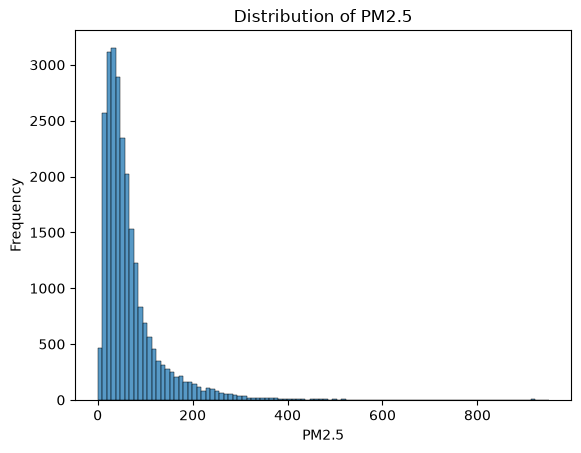

In [8]:
#Visualize PM2.5 distribution
sns.histplot(data=df, x='PM2.5', bins=100)
plt.title('Distribution of PM2.5')
plt.ylabel('Frequency')
plt.show()

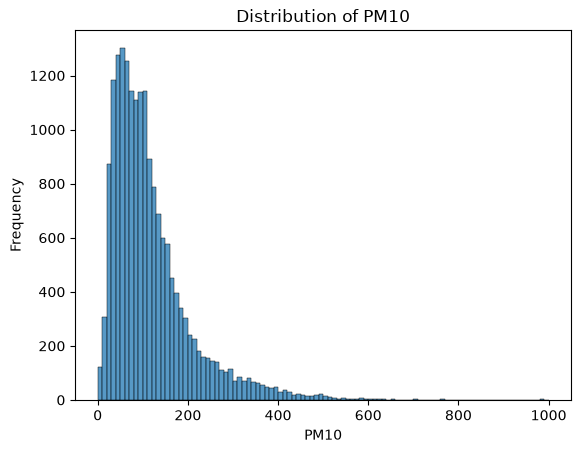

In [9]:
#Visualize PM10 distribution
sns.histplot(data=df, x='PM10', bins=100)
plt.title('Distribution of PM10')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 0, 'AQI Level')

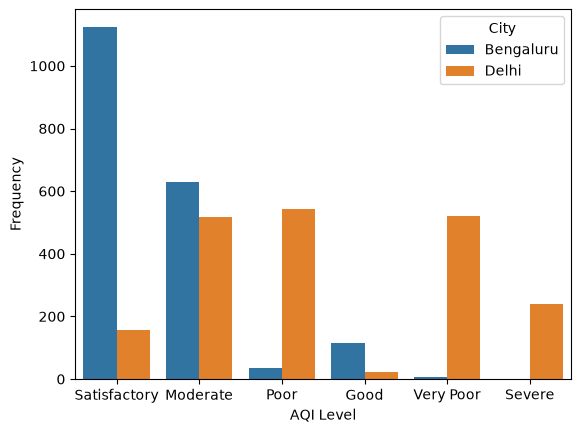

In [10]:
cities = ["Delhi", "Bengaluru"]
filtered_df = df[df["City"].isin(cities)]
sns.countplot(x='AQI_Bucket', data=filtered_df, hue="City")
plt.ylabel('Frequency')
plt.xlabel('AQI Level')

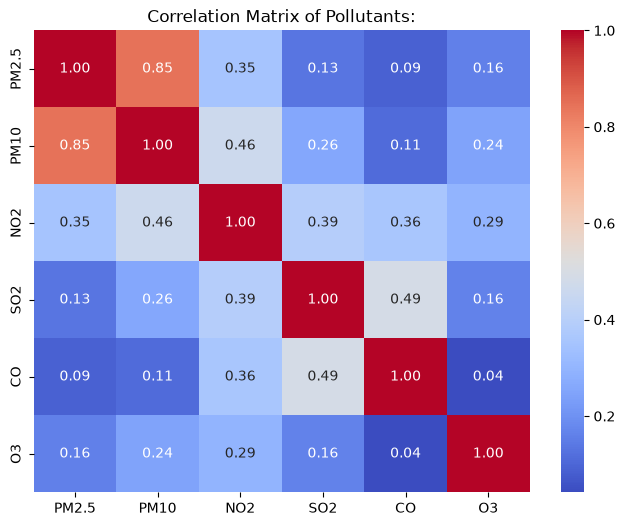

In [11]:
#Correlation heatmap for Major Pollutants
numeric_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Pollutants:')
plt.show()

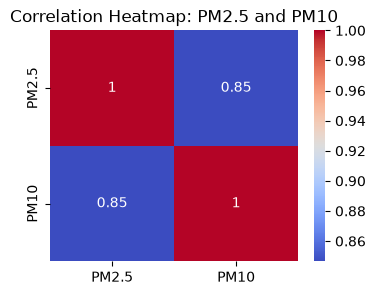

In [12]:
#Correlation heatmap for PM2.5 and PM10
filtered2_df = df[['PM2.5', 'PM10']]

corr_matrix = filtered2_df.corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: PM2.5 and PM10')
plt.show()

## Data Cleaning:

- Handled missing values by imputing the median pollutant value per city to retain local patterns.
- Standardized formats: converted date strings; extracted year, month, and day; and normalized city names.
- Removed impossible and extreme outlier values from pollutant data, using IQR filtering and logical checks.
- Ensured no duplicates remained, maintaining unique data integrity.

In [13]:
#Remove rows in which target column 'AQI' is a missing value.
df = df.dropna(subset=['AQI'])

#Train/Test split (80/20) on whole dataframe
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42
)

Missing values in the dataset:
City              0
Date              0
PM2.5           538
PM10           5662
NO              304
NO2             308
NOx            1483
NH3            5228
CO              344
SO2             486
O3              627
Benzene        2808
Toluene        4661
Xylene        12282
AQI               0
AQI_Bucket        0
dtype: int64


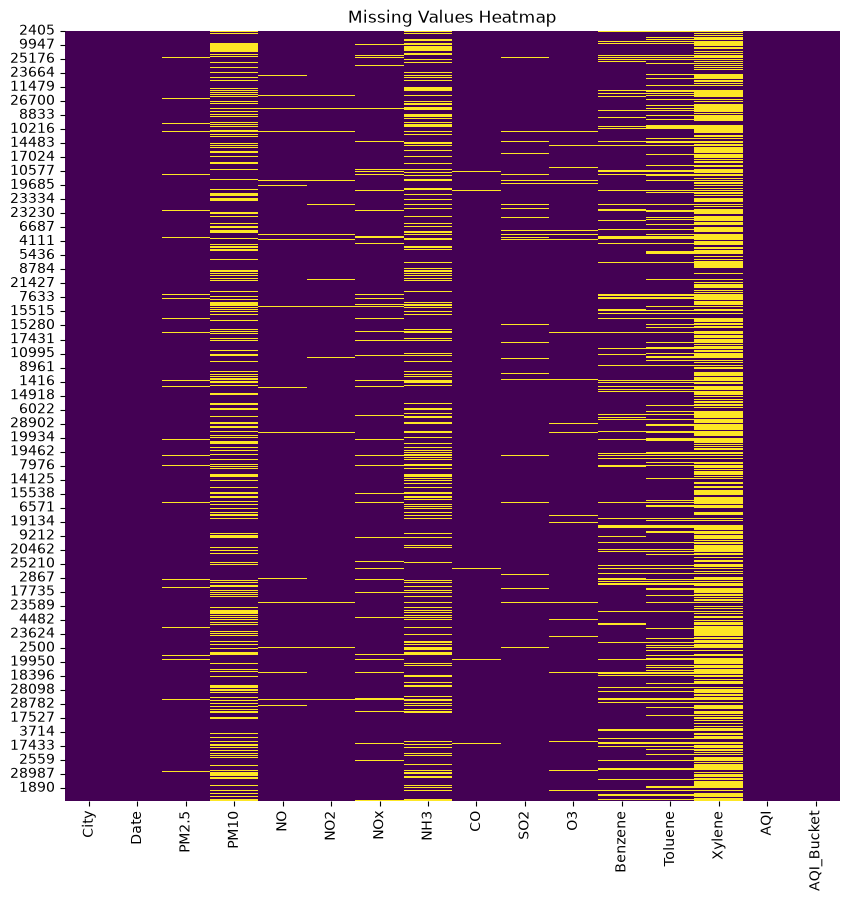

In [14]:
missing_values = df_train.isnull().sum()
print(f"Missing values in the dataset:\n{missing_values}")

plt.figure(figsize=(10, 10))
sns.heatmap(df_train.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Impute missing values in all pollutant columns by city-specific median.
exclude_cols = ['AQI', 'AQI_Bucket', 'City', 'Date']

pollutant_columns = [
    col for col in df_train.select_dtypes(include=[float, int]).columns
    if col not in exclude_cols
]
for col in pollutant_columns:
    city_medians = df_train.groupby('City')[col].median()
    df_train[col] = df_train[col].fillna(df_train['City'].map(city_medians))
    df_test[col] = df_test[col].fillna(df_test['City'].map(city_medians))

#Any leftover missing values (where a city had no median) filled with the overall column median.
for col in ['PM10', 'O3', 'NOx', 'NH3', 'Benzene', 'Toluene', 'Xylene']:
    if df_train[col].isnull().sum() > 0:
        median_value = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_value)

    if df_test[col].isnull().sum() > 0:
        median_value = df_train[col].median()
        df_test[col] = df_test[col].fillna(median_value)

Missing values in the dataset(training) after Imputing:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


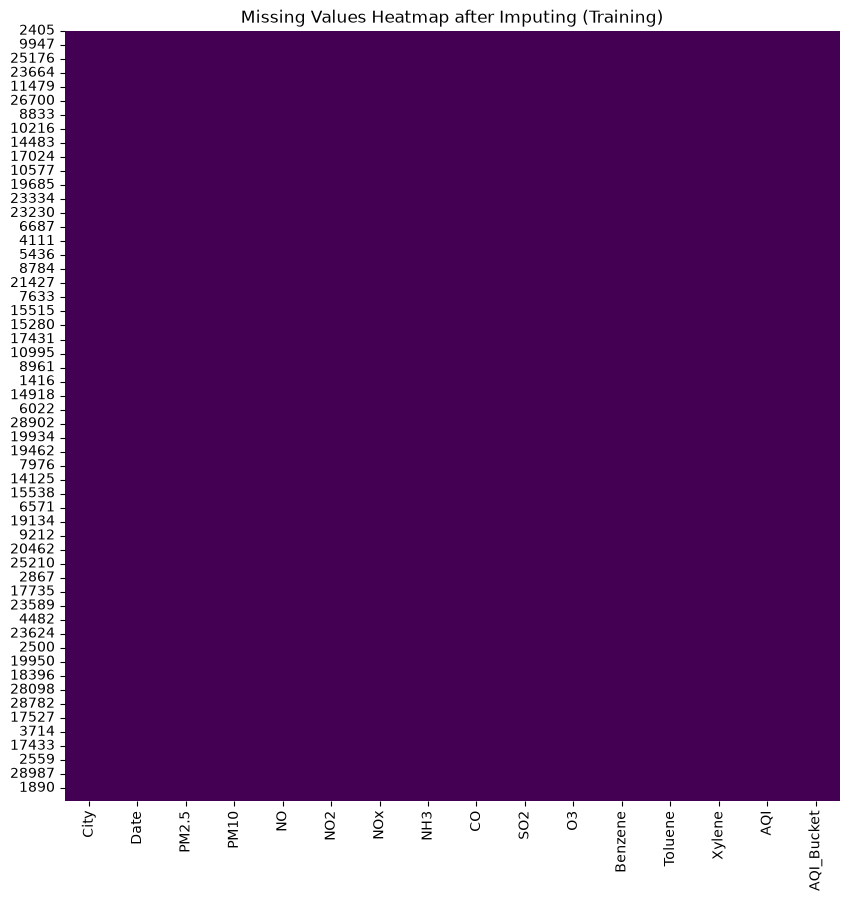

Missing values in the dataset(testing) after Imputing:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


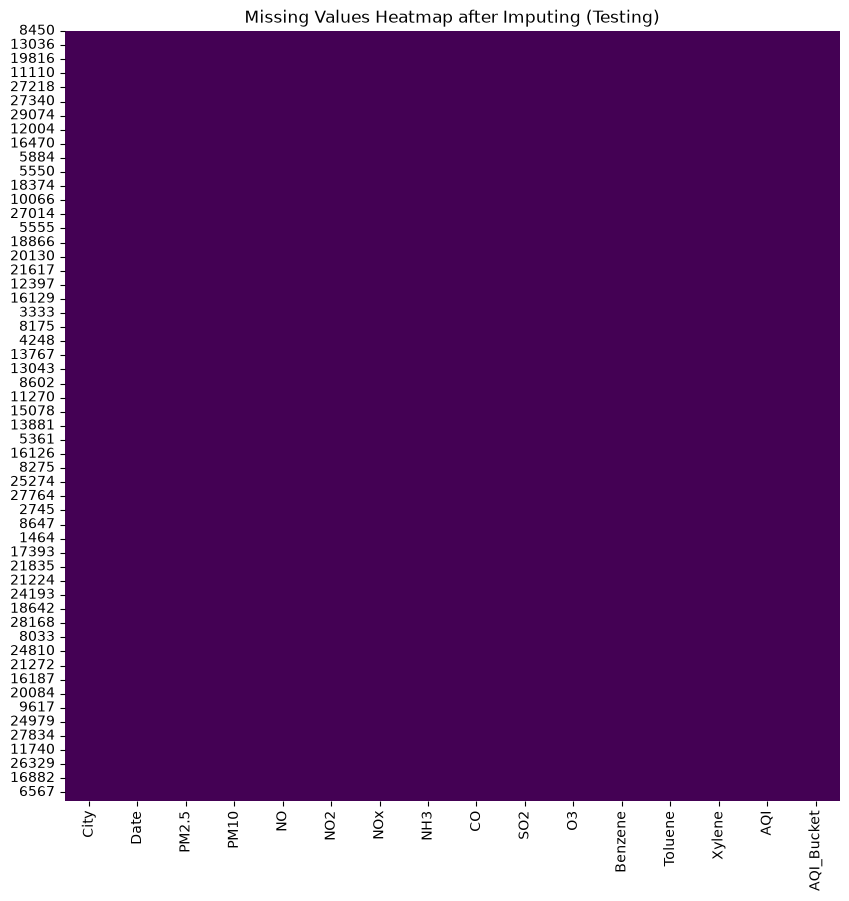

In [15]:
missing_values_train = df_train.isnull().sum()
print(f"Missing values in the dataset(training) after Imputing:\n{missing_values_train}")

plt.figure(figsize=(10, 10))
sns.heatmap(df_train.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap after Imputing (Training)")
plt.show()

missing_values_test = df_test.isnull().sum()
print(f"Missing values in the dataset(testing) after Imputing:\n{missing_values_test}")

plt.figure(figsize=(10, 10))
sns.heatmap(df_test.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap after Imputing (Testing)")
plt.show()

In [16]:
#Skewness & kurtosis for all numeric features (Only on training set to avoid data leakage)
df_num = df_train.select_dtypes(include=['float64', 'int64'])

skewness = df_num.skew()
print(f"Skewness for each numerical column:\n{skewness}")

kurtosis_metric = df_num.kurtosis()
print(f"\nKurtosis for each numerical column:\n{kurtosis_metric}")

Skewness for each numerical column:
PM2.5       2.819378
PM10        2.166354
NO          3.588795
NO2         2.480847
NOx         2.550500
NH3         4.481434
CO          8.407592
SO2         3.943882
O3          1.359647
Benzene    23.709853
Toluene    12.395658
Xylene     12.597612
AQI         3.473258
dtype: float64

Kurtosis for each numerical column:
PM2.5       12.442783
PM10         7.343792
NO          20.126013
NO2         11.524736
NOx          9.585376
NH3         34.561653
CO          94.451421
SO2         20.669701
O3           3.766621
Benzene    661.790248
Toluene    246.847688
Xylene     299.195421
AQI         22.209936
dtype: float64


In [17]:
Q1 = df_train.select_dtypes(include=['float64', 'int64']).quantile(0.25)
Q3 = df_train.select_dtypes(include=['float64', 'int64']).quantile(0.75)
IQR = Q3 - Q1

num_df = df_train.select_dtypes(include=['float64', 'int64'])
outliers = ((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).sum()

print(f"Outliers detected based on IQR method:\n{outliers}")

z_scores = np.abs(stats.zscore(df_train.select_dtypes(include=['float64', 'int64'])))
outliers_test = (z_scores > 2).sum()
print(f"\nOutliers detected using Z-score:{outliers_test}")

#IQR method for outlier removal(train)
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_train[col] = np.where(df_train[col] < lower_bound, lower_bound, df_train[col])
    df_train[col] = np.where(df_train[col] > upper_bound, upper_bound, df_train[col])

#IQR method for outlier removal(test)
numeric_cols = df_test.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    Q1 = df_test[col].quantile(0.25)
    Q3 = df_test[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_test[col] = np.where(df_test[col] < lower_bound, lower_bound, df_test[col])
    df_test[col] = np.where(df_test[col] > upper_bound, upper_bound, df_test[col])

Outliers detected based on IQR method:
PM2.5      1615
PM10       1254
NO         1908
NO2         888
NOx        1561
NH3         905
CO         1854
SO2        1964
O3          579
Benzene    1423
Toluene    2525
Xylene     9864
AQI        1083
dtype: int64

Outliers detected using Z-score:9462


In [18]:
#Checking Multicollinearity using Variance Inflation Factor (VIF)
df_train_with_const = add_constant(df_train[['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']])

vif_data = pd.DataFrame()
vif_data['Feature'] = df_train_with_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(df_train_with_const.values, i)
    for i in range(df_train_with_const.shape[1])
]

vif_data = vif_data[vif_data.Feature != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(f"Variance Inflation Factor (VIF) Scores for major pollutants:\n {vif_data}")

Variance Inflation Factor (VIF) Scores for major pollutants:
   Feature       VIF
0   PM2.5  2.051025
1    PM10  1.949889
2     NO2  1.465350
3      CO  1.272874
4     SO2  1.249604
5      O3  1.149640


Clean from here:

## Feature Engineering

- Created new time-based features (Year, Month, Day, DayOfWeek) to enable temporal modeling.
- One-hot encoded categorical features (City, AQI_Bucket) for algorithm compatibility.
- Engineered a combined “BTX” feature to summarize total volatile organic compound load (from benzene, toluene, and xylene).
- Added derived ratio and aggregation features (e.g., PM2.5/PM10 ratio, mean pollutant) to enhance predictive power.

In [19]:
#Standardize date and extract features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [20]:
# Create a new feature representing the mean value of the primary pollutants (helps summarize overall pollution exposure).
df['Mean_Pollutant'] = df[['PM2.5','PM10','NO2','SO2','CO','O3']].mean(axis=1)

##Combined VOC Feature (BTX):

Benzene, toluene, and xylene are closely linked volatile organic compounds from similar emission sources. To summarize and strengthen their influence, a new feature BTX_sum is created by adding these three columns, providing a single indicator of total VOC exposure.


In [21]:
#Combine Benzene, Toluene, and Xylene into a BTX_sum feature
df['BTX_sum'] = df[['Benzene', 'Toluene', 'Xylene']].sum(axis=1)

#Milestone 2: Model Development Report

## Model Selection

The objective of this project is to predict the Air Quality Index (AQI), which is a continuous numeric value derived from various pollutant concentrations. So, I have chosen to use **Multiple Linear Regression**.
### Model Justification

Multiple Linear Regression is a good choice for this project because it is well-suited for predicting a continuous outcome (AQI) using multiple numeric features (pollutants). Its main advantages are interpretability i.e helping to understand how each pollutant impacts AQI and efficiency, whih results in fast training and straightforward analysis. It also serves as a solid baseline before exploring more complex methods.

However, this model assumes linear relationships between pollutants and AQI, which may not capture deeper, nonlinear interactions. It can also be sensitive to outliers and to correlated inputs (multicollinearity), although most of these issues have been mitigated by some data cleaning techniques.

Given that my dataset is numeric, well-preprocessed, and that interpretability is valuable for air quality analysis, multiple linear regression is an appropriate and practical model for this task.

In [22]:
#Features (columns) to be used to predict AQI
model_features = ['PM2.5', 'PM10', 'SO2', 'CO', 'NO2', 'O3']
target_col = 'AQI'

X_train, y_train = df_train[model_features], df_train[target_col]
X_test, y_test = df_test[model_features], df_test[target_col]

#Standardizing features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#Fit ordinary least squares (OLS)
model = LinearRegression()
model.fit(X_train_s, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[65.81, 8.22,11.39,26.82, 7.29, 1.31]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[228.6 ,138.35,131.82,115.83,105.16, 77.67]"


## Model Training

The cleaned dataset was split into training and testing sets using an 80/20 ratio. Since no major multicollinearity was detected among the features (verified by calculating VIF), OLS regression can be used directly without regularization.
No hyperparameter tuning or cross-validation was necessary for this baseline model. The model was trained on the training set and then evaluated on the test set.

Baseline RMSE (predicting mean AQI): 103.269
Root Mean Squared Error (RMSE): 45.47
Mean Squared Error (MSE): 2067.239
Mean Absolute Error (MAE): 31.24
R² Score: 0.806


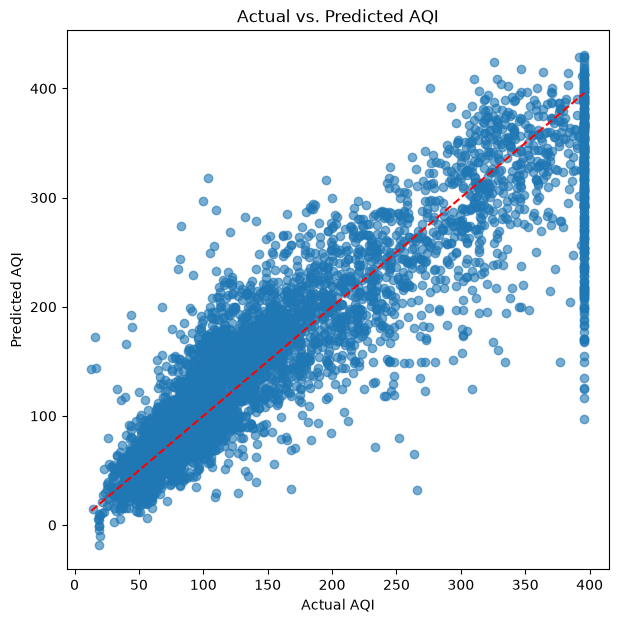

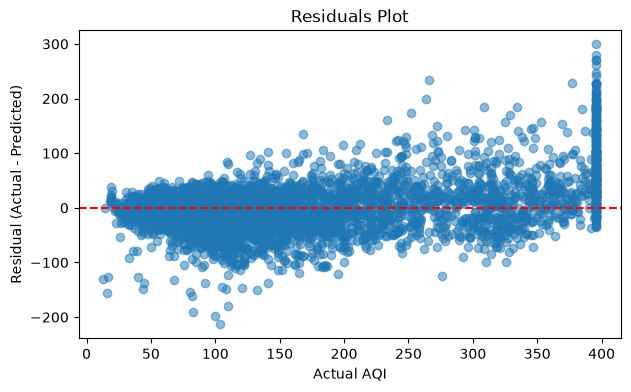

In [23]:
# Predict AQI values on the test set using the trained OLS model and scaled features
y_pred = model.predict(X_test_s)

#Calculate RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

#Calculate R-squared score
r2 = r2_score(y_test, y_pred)

#Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

#Calculate baseline RMSE
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline RMSE (predicting mean AQI): {baseline_rmse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.3f}")

#Actual vs. Predicted AQI
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs. Predicted AQI")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(7,4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual AQI')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals Plot')
plt.show()

### Model Evaluation Results

The Ordinary Least Squares (OLS) multiple linear regression model achieved an RMSE of **45.7** and an R² score of **0.805** on the test set. This indicates that, on average, predictions are within roughly 46 AQI units of the true values, and that the model explains over 80% of the variance in AQI. This suggests multiple linear regression is a solid baseline for this dataset and feature set.

## 1. Final Model Performance Analysis

The primary objective of this project is to develop a predictive model for the Air Quality Index (AQI) of Indian cities using six key pollutant features: PM2.5, PM10, SO2, CO, NO, and O3. This section compares the performance of the Multiple Linear Regression model with two alternative models: RandomForest Regressor model & Elastic Net Regression model.

In [24]:
#Linear regression model results
y_pred_lr = model.predict(X_test_s)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  MAE : {mae_lr:.2f}")
print(f"  R²  : {r2_lr:.3f}")

#Random Forest regressor results
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE : {mae_rf:.2f}")
print(f"  R²  : {r2_rf:.3f}")

#Elastic Net Regression results
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
enet.fit(X_train_s, y_train)

y_pred_enet = enet.predict(X_test_s)

rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
mae_enet  = mean_absolute_error(y_test, y_pred_enet)
r2_enet   = r2_score(y_test, y_pred_enet)

print("\nElastic Net Regression:")
print(f"  RMSE: {rmse_enet:.2f}")
print(f"  MAE : {mae_enet:.2f}")
print(f"  R²  : {r2_enet:.3f}")

Linear Regression:
  RMSE: 45.47
  MAE : 31.24
  R²  : 0.806

Random Forest Regressor:
  RMSE: 32.15
  MAE : 19.93
  R²  : 0.903

Elastic Net Regression:
  RMSE: 45.49
  MAE : 31.46
  R²  : 0.806


The OLS model achieved a strong baseline performance, explaining over 80% (R^2=0.805) of the variance in AQI, confirming the high predictive power of the major pollutant features. The Elastic Net model, provided robustness through L1/L2 regularization, but the model showed insignificant improvement in performance (RMSE=45.82), suggesting issues like multicollinearity or overfitting was not a major issue.

The Random Forest Regressor was clearly the best-performing model, achieving an R^2 score of 0.904. This means that the non-linear relationships and complex interactions between the six pollutant features contribute for a significant portion of the remaining variance, improving predictive capability by reducing the RMSE by approximately 30% compared to the OLS multiple linear regression model.

### Final Model for Deployment

The Random Forest above was trained with default settings to fairly compare model
architectures. For deployment, though, the serialized model has to stay small enough
for free-tier hosting (Render) and GitHub's file size limits — the default RF
serializes to roughly 160MB. Capping `max_depth` bounds how deep any individual tree
can grow, which directly bounds the number of nodes (and therefore the file size).
The cell below retrains the Random Forest with `max_depth=14` and re-evaluates on the
test set to confirm this costs negligible accuracy before it becomes the model
actually shipped in the API.

In [25]:
#Random Forest regressor results, version 2
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=14)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE : {mae_rf:.2f}")
print(f"  R²  : {r2_rf:.3f}")



Random Forest Regressor:
  RMSE: 32.19
  MAE : 19.98
  R²  : 0.903


### Saving the Model Artifact

Both the trained model and the fitted `StandardScaler` are persisted with `joblib`,
which handles the large NumPy arrays inside a fitted scikit-learn model more
efficiently than plain `pickle`, and supports compression to shrink the file further.
Both objects are needed at inference time — the scaler must apply the exact same
mean/std learned from training data to any new pollutant reading before the model can
produce a valid prediction, so saving the model without the scaler would leave the
backend with no way to reproduce that transformation. `compress=3` trades a bit of
save/load speed for a smaller file.


In [26]:
joblib.dump(rf, 'aqi_model.joblib', compress=3)
joblib.dump(scaler, 'scaler.joblib', compress=3)

['scaler.joblib']

## Limitations and Potential Improvements:
Even though the Random Forest model achieves the best predictive performance, and the linear models are interpretable, there are several limitations:
1. The linear models (OLS and Elastic Net) assume that the features have a linear relationship with each other and cannot capture complex nonlinear patterns or interactions.  
2. While, the Random Forest Regressor captures nonlinearities, it is less interpretable and may require careful tuning to avoid overfitting.
3. All models only use pollutant concentrations to predict AQI. Important factors such as temperature, humidity, wind, season, and other city specific factors are not taken into account by any of the models.


To address the current model's dependance solely on pollutant data, in the future the model should incorporate additional environmental and temporal features such as temperature, humidity, wind patterns, and explicit time-series encoding (e.g., month, season, lag effects of previous days' AQI), performing more systematic hyperparameter tuning for Elastic Net and Random Forest.

## 3. Ethical Considerations

My AQI prediction project has direct connections to public health and environmental policy. As such, it raises important ethical questions about who benefits, who might be harmed, and how the model's outputs are used in practice.

#### Societal Impacts and Stakeholder Effects

1. Predicted AQI values can influence a wide range of behaviors and decisions, such as outdoor activity, school operations, and workplace policies. If the model does not accuractely predict the AQI, it may lead to the vulnerable population (senior citzens, children, people with breathing issues such as asthma) exposed to much more harmful air than they think. So, uncertainty and known limitations (e.g., higher error at extreme AQI values) should be communicated clearly.

2. Different stakeholders such as residents, public health agencies, city planners, businesses may all rely on the model to some extent. Misinterpretation or over-reliance on the predictions of the model without understanding its limitations may lead to poor decision-making, such as delayed responses to severe pollution episodes.

#### Recommendations for ensuring fairness, accountability, and compliance with regulations
Fairness requires checking performance across different locations, seasons, and potentially vulnerable communities, explicitly documenting where the model is less reliable, which areas do not provide adequate input for a confidently accurate predction to be made and prioritizing improvements in those under-served areas.

Accountability will be ensured by keeping the model as interpretable as possible, clearly explaining how the AQI predictions are generated, and ensuring that the model's results are only utilized to support decision rather than the sole basis for decision-making.

Compliance with regulations will be ensured by protecting any linked or integrated data according to privacy and data-protection laws, securing APIs and storage, and maintaining sufficient documentation and logging (e.g., model versions) to support auditing whenever needed.